#### 1.数据初始化及定义

In [ ]:
import json
import copy
from torch.utils.data import Dataset
import datas



class RaftLogDataSet(Dataset):
    def __init__(self, datafilesName):
        self.datafilesName = datafilesName
        self.serversOrignDatas = []
        for fileName in datafilesName:
           with open(fileName, 'r') as f:
                lines = f.readlines()
                tmp = []
                for line in lines:
                    if len(line) < 2:continue
                    js_data = json.loads(line)
                    tmp.append(js_data)
                self.serversOrignDatas.append(tmp)
                f.close()
                
        self.all_servers_datasets = []
        for serverOrignData in self.serversOrignDatas:
            flattend_jsons = []
            for js_data in serverOrignData:
                if ('role' not in js_data) or (line is None) or ('timestamp' not in js_data):
                    continue
              
                keys =datas.flattenJsonKeys(js_data)
                values =datas. flattenJsonValue(js_data)
                js_data = {}
                for i in range(len(keys)):
                    js_data[keys[i]] = values[i]
                flattend_jsons.append(js_data)
            self.all_servers_datasets.append(flattend_jsons)
            
        combined_actionTuples = []
        '''
        combined_actionTuples :[ (timestamp,[(serverId,actionJson,index) ... ]) ... ]
        '''
        def timestampIsExistInTuples(combined_actionTuples,timeStamp) -> int:
            for i in range(len(combined_actionTuples)):
                if combined_actionTuples[i][0] == timeStamp:
                    return i
            return -1
        
        def getPrevStateJsonInServerByIndex(serverId,actionIndex):
            serverDatas = self.all_servers_datasets[serverId]
            for i in range(actionIndex,-1,-1):
                if serverDatas[i]['role'] == 'state':
                    return serverDatas[i]
            return None

        def getNextStateJsonInServerByIndex(serverId,actionIndex):
            serverDatas = self.all_servers_datasets[serverId]
            for i in range(actionIndex,len(serverDatas)):
                if serverDatas[i]['role'] == 'state':
                    return serverDatas[i]
            return None
        
        for serverId in range(len(self.all_servers_datasets)):
            serverDatas = self.all_servers_datasets[serverId]
            for i  in range(len(serverDatas)):
                json_data = serverDatas[i]
                if(json_data['role'] != 'action'):continue
                timestamp = json_data['timestamp']
                idx = timestampIsExistInTuples(combined_actionTuples,timestamp)
                tuple_ = (serverId,json_data,i)
                if idx == -1:
                    combined_actionTuples.append((timestamp,[tuple_]))
                else:   
                    combined_actionTuples[idx][1].append(tuple_)
                    
        self.train_data_each_batch_by_logicOrder = []
        for tp_ in combined_actionTuples:
            # tp_ : (timestamp,[(serverId,actionJson,index) ... ])
            actionTupleList = tp_[-1]
            grouped_by_serverId = {}
            for actionTuple in actionTupleList:
                # actionTuple : (serverId,actionJson,index)
                serverId = actionTuple[0]
                if serverId not in grouped_by_serverId:
                    grouped_by_serverId[serverId] = []
                grouped_by_serverId[serverId].append(actionTuple)
                
            batch_tuple = {}
            for serverId in grouped_by_serverId:
                batch_tuple[serverId] = {
                    'prevStateJson' : None,
                    'actions' : [],
                    'nextStateJson':None
                }
                actionTuples = grouped_by_serverId[serverId]
                prevStateJson = None
                nextStateJson = None
                # actionTuple: (serverId,actionJson,index)
                for actionTuple in actionTuples:
                    actionJson = actionTuple[1]
                    index = actionTuple[2]
                    if prevStateJson is None:
                        prevStateJson = getPrevStateJsonInServerByIndex(serverId,index)
                    if nextStateJson is None:
                        nextStateJson = getNextStateJsonInServerByIndex(serverId,index)
                    batch_tuple[serverId]['actions'].append(actionJson)
                batch_tuple[serverId]['prevStateJson'] = prevStateJson
                batch_tuple[serverId]['nextStateJson'] = nextStateJson
            self.train_data_each_batch_by_logicOrder.append(batch_tuple)
          

    def __getitem__(self, index):
        
        if(index >= len(self.train_data_each_batch_by_logicOrder) or index < 0):
            raise IndexError("Index out of range")
        batch_tuple = self.train_data_each_batch_by_logicOrder[index]
        once_prevStateJson = []
        once_actions = []
        once_nextStateJson = []
        for serverId in batch_tuple:
            item = batch_tuple[serverId]
            prevStateJson = item['prevStateJson']
            nextStateJson = item['nextStateJson']
            actions = item['actions']
            once_prevStateJson.append(prevStateJson)
            once_nextStateJson.append(nextStateJson)
            once_actions.append(actions)  
        return (once_prevStateJson,once_actions,once_nextStateJson  )
    
    def __len__(self):
        return len(self.train_data_each_batch_by_logicOrder)


In [ ]:
datafilesName = ['/home/cdy/code/projects/cRaft/.data/system_data/server-128-0/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/.data/system_data/server-130-1/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/.data/system_data/server-131-2/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/.data/system_data/server-133-3/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/.data/system_data/server-134-4/system_runtime.data0',
                ]
dataset = RaftLogDataSet(datafilesName)


#### 2.构建网络

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class StateCriticNetwork(nn.Module):
    def __init__(self, input_channels, input_width, embed_dim, num_heads=8):
        super(StateCriticNetwork, self).__init__()
        self.input_channels = input_channels 
        self.input_width = input_width 
        self.embed_dim = embed_dim 
        self.num_heads = num_heads  
        self.cov_channels = 64
    
        self.conv1 = nn.Conv1d(in_channels=self.input_channels, out_channels=self.cov_channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=self.cov_channels, out_channels=self.cov_channels, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv1d(in_channels=self.cov_channels, out_channels=self.embed_dim, kernel_size=3, stride=1, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)  # 将序列长度压缩为1
        
       
        self.linear1 = nn.Linear(self.embed_dim, self.embed_dim)
        self.residual_linear = nn.Linear(self.embed_dim, self.embed_dim)
        
        
        self.multihead_attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=self.num_heads)
        
       
        self.output_linear1 = nn.Linear(self.embed_dim, self.embed_dim // 2)
        self.output_linear2 = nn.Linear(self.embed_dim // 2, 1)

    def forward(self, x):
        # x shape: (batch_size, input_channels, input_width)
        
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.dropout(x,0.3,True)
        x = torch.relu(x)
        x = self.conv3(x)
        x = torch.relu(x)
        
        # Pooling to reduce sequence length to 1
        x = self.pool(x).squeeze(-1)  # Shape after pooling: (batch_size, embed_dim)
        
        x = torch.relu(self.linear1(x))
        residual = torch.relu(self.residual_linear(x))
        
        attn_input = x.unsqueeze(1).transpose(0, 1)  # Shape: (1, batch_size, embed_dim)
        
        attn_output, _ = self.multihead_attention(attn_input, attn_input, attn_input)
        
      
        attn_output = attn_output.transpose(0, 1).squeeze(1)  # Shape: (batch_size, embed_dim)
        
     
        attn_output += 0.5 * residual
        output =  torch.relu(self.output_linear1(attn_output))
        output= torch.dropout(output,0.3,True)
        output = self.output_linear2(output)
       
        return output

#### 3.初始化batch

In [ ]:
import torch
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_width = 98 # StateJson 的特征维度
embed_dim = 512
batchs = []
one_batch_x = []
one_batch_y = []
batch_size = 50
for i in range(len(dataset)):
    once_prevStateJson,once_actions,once_nextStateJson = dataset[i]
    if len(once_prevStateJson) != 5:continue
    if(len(one_batch_x) == batch_size):
        batchs.append((one_batch_x,one_batch_y))
        one_batch_x = []
        one_batch_y = []
    x = []
    for serverId in range(len(once_prevStateJson)):
        prevStateJson = once_prevStateJson[serverId]
        if(prevStateJson is None):continue  
        actions = once_actions[serverId]
        nextStateJson = once_nextStateJson[serverId]
        prevStateJson = datas.handleStateJson(prevStateJson)
        x.append(list(prevStateJson.values()))
    if(len(x) != 5)   :continue
    y_label = 0
    for serverId in range(len(once_actions)):
        actions = once_actions[serverId]
        if('duration' not in  actions[0]): continue
        y_t = []
        for action in actions:
            y_t.append(action['duration'])
            # if(action['is_ok']):
            #     y_t.append(action['duration'])
            # else:
            #     y_t.append(150)
        if(len(y_t) == 0):continue
        y_label +=sum(y_t)/len(y_t)
    
    one_batch_x.append(x)
    one_batch_y.append(y_label)
    
if(len(one_batch_x) > 0):
    batchs.append((one_batch_x,one_batch_y))
print(len(batchs))

In [ ]:
num_eopchs = 50
num_servers = len(datafilesName)
input_channels = num_servers
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_width = 98
embed_dim = 512
num_heads = 8
lr = 0.0001
train_ratio = 0.85
#####################
model = StateCriticNetwork(input_channels,input_width,embed_dim,num_heads).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
model.train()
###########################
avg_loss = []
losses = []
test_loss = []
random.shuffle(batchs)

train_len = int(len(batchs) * train_ratio)
train_batchs = batchs[:train_len]
test_batchs = batchs[train_len:]
for epoch in range(num_eopchs):
    random.shuffle(train_batchs)
    model.train()

    for (batch_x,batch_y) in train_batchs:
        input_x = torch.tensor(batch_x,dtype=torch.float).to(device)
        y_label =  torch.tensor(batch_y,dtype=torch.float).to(device)
        y_label =  torch.log(1+ torch.clamp(y_label,min=0)).to(device)
        output = model(input_x)
        output = torch.log(1+ torch.clamp(output,min=0))
        loss = loss_fn(output, y_label)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        print(epoch,loss.item())
        losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # eval model
    model.eval()
    for batch_x,batch_y in test_batchs:
        input_x = torch.tensor(batch_x,dtype=torch.float).to(device)
        y_label =  torch.tensor(batch_y,dtype=torch.float).to(device)
        y_label =  torch.log(1+ torch.clamp(y_label,min=0)).to(device)
        output = model(input_x)
        output = torch.log(1+ torch.clamp(output,min=0))
        loss = loss_fn(output, y_label)
        test_loss.append(loss.item())
    # tmp_avg_loss = sum(temp_loss) / len(temp_loss)
    # if(epoch >= 5 and tmp_avg_loss < min_test_loss):
    #     min_test_loss = tmp_avg_loss
    #     torch.save(model, f'{epoch}-{min_test_loss}-model.pth')
        
print("train done")

In [ ]:
# calculate the last test loss
last_test_loss = []
model.eval()
    
for batch_x,batch_y in test_batchs:
    input_x = torch.tensor(batch_x,dtype=torch.float).to(device)
    y_label =  torch.tensor(batch_y,dtype=torch.float).to(device)
    y_label =  torch.log(1+ torch.clamp(y_label,min=0)).to(device)
    output = model(input_x)
    output = torch.log(1+ torch.clamp(output,min=0))
    loss = loss_fn(output, y_label)
    last_test_loss.append(loss.item())
print("last test loss:",sum(last_test_loss)/len(last_test_loss))

In [ ]:
# f = open('../out/loss.txt','w')
# for item in losses:
#     f.write(str(item) + '\n')
# f.close()
# f = open('../out/test_loss.txt','w')
# for item in test_loss:
#     f.write(str(item) + '\n')
# f.close()
# f = open('../out/last_test_loss.txt','w')
# for item in last_test_loss:
#     f.write(str(item) + '\n')
# f.close()
# # torch.save(model, '../model/state_critic_model.pth')

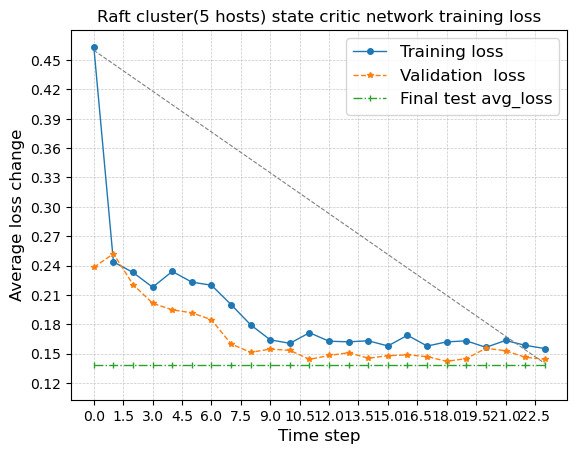

In [3]:
from matplotlib import pyplot as plt
import numpy as np
def readLossFileToList(fileName):
    with open(fileName, 'r') as f:
        lines = f.readlines()
        losses = []
        for line in lines:
            if len(line) < 2:continue
            losses.append(float(line))
        f.close()
    return losses

def average_k_elements(lst, k):
    if k <= 0:
        raise ValueError("K must be a positive integer greater than zero.")
    averages = []
    for i in range(0, len(lst), k):
        group = lst[i:i+k]  
        group_average = sum(group) / len(group)  
        averages.append(group_average)  
    return averages



k = 1000
losses_list = readLossFileToList('../out/loss.txt')
test_loss_list = readLossFileToList('../out/test_loss.txt')
last_test_loss_list = readLossFileToList('../out/last_test_loss.txt')
# losses_list = losses
# test_loss_list = test_loss
# last_test_loss_list = last_test_loss
result = average_k_elements(losses_list[:],k)
plt.xticks(np.arange(0, 24, 1.5))  # 从0到10，间隔为2
plt.yticks(np.arange(0.12, 0.46, 0.03))  # 从-1到1，间隔为0.5

# 添加网格线
plt.grid(linewidth=0.5,alpha = 0.7,linestyle='--')

plt.title('Raft cluster(5 hosts) state critic network training loss')
#设置x轴标签
plt.xlabel('Time step',fontsize=12)
#设置y轴标签
plt.ylabel('Average loss change',fontsize=12)

plt.plot(result,marker='o',markersize=4,linewidth=1,label='Training loss')
plt.plot(average_k_elements(test_loss_list[:],180),marker='*',markersize=4,linewidth=1,linestyle='--',label='Validation  loss')
plt.plot([sum(last_test_loss_list)/len(last_test_loss_list)] * len(result),marker='|',markersize=4,linewidth=1,linestyle='-.',label='Final test avg_loss')
plt.legend(fontsize=12)


#为了显示美观
x = [0,23]
y = [0.46,0.140]
plt.plot(x,y,c='gray',linewidth=0.8,linestyle='--')
plt.plot([0.12] * 1,c='white',marker='^',markersize=0.001,linewidth=0.0000001)
plt.savefig('../out/cluster_loss-1200.png',dpi = 1200)

In [ ]:
# import torch

# # # 假设你有一个已经训练好的模型
# model = torch.load('/home/cdy/code/projects/cRaft/src/train/model/best-state_critic-model.pth')  # 加载你的模型
# # 转换为 TorchScript 模型
# model.eval()
# scripted_model = torch.jit.script(model)  # 或者使用 torch.jit.trace(model, example_input)
# # 保存为 TorchScript 格式
# scripted_model.save('../model/best_state_critic_cxx_model_scripted.pt')